# Data Evaluator

## Install libraries

In [228]:
# Standard library
import os
import random
import sys

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.constants import *
from utils.utils import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from ta.ta_functions import *

load_dotenv()

True

In [229]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Parameters

In [230]:
STOCK_CODE = "VIC"
LOOKBACK_WINDOW = 50
FORECAST_HORIZON = 5

In [231]:
STOCK_CODE = str.lower(STOCK_CODE)
STOCK_CODE

'vic'

## Load data

In [232]:
INPUT_FOLDER_PATH = DATA_EVALUATOR_INPUT_FOLDER_PATH
INPUT_FOLDER_PATH

'../../train_test_set'

In [233]:
STOCK_CODE_INPUT_FOLDER_PATH = os.path.join(
    INPUT_FOLDER_PATH, f"{STOCK_CODE}_{LOOKBACK_WINDOW}_{FORECAST_HORIZON}"
)
STOCK_CODE_INPUT_FOLDER_PATH

'../../train_test_set\\vic_50_5'

In [234]:
META_DATA = json.load(open(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "metadata.json")))
META_DATA

{'stock_code': 'vic',
 'lookback_window': 50,
 'forecast_horizon': 5,
 'train_range': ['2000-01-01', '2021-12-31'],
 'val_range': ['2022-01-01', '2023-12-31'],
 'test_range': ['2024-01-01', '2026-04-30']}

In [235]:
dates_train = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "dates_train.npy"))
dates_train.shape

(3459,)

In [236]:
dates_val = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "dates_val.npy"))
dates_val.shape

(439,)

In [237]:
dates_test = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "dates_test.npy"))
dates_test.shape

(510,)

In [238]:
train_featured_stock_df = pd.read_csv(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "train_featured_stock_df.csv")
)
train_featured_stock_df

,code,date,close,adjust,change,matching_volume,matching_value,open,high,low,...,ad_direction,ad_signal_10,ad_signal_10_slope,ad_hist_10,ad_hist_10_slope,ad_hist_10_acceleration,ad_hist_10_gt_0,ad_hist_10_lt_0,ad_hist_10_abs,ad_10_strength
0,VIC,2007-09-21,137.0,2.66,6.0,1224660,167.40,137.0,137.0,135.0,...,1,4.854060e+05,340898.677686,1.534044e+06,8.837613e+05,2.334786e+05,True,False,1.534044e+06,1.878682e+12
1,VIC,2007-09-24,143.0,2.78,6.0,551130,78.81,143.0,143.0,143.0,...,-1,7.643231e+05,278917.099925,1.255127e+06,-2.789171e+05,-1.162678e+06,True,False,1.255127e+06,0.000000e+00
2,VIC,2007-09-25,150.0,2.92,7.0,962110,144.30,150.0,150.0,148.0,...,1,1.167457e+06,403133.990848,1.814103e+06,5.589760e+05,8.378931e+05,True,False,1.814103e+06,1.745367e+12
3,VIC,2007-09-26,157.0,3.05,7.0,781900,122.58,157.0,157.0,154.0,...,1,1.639458e+06,472000.537966,2.124002e+06,3.098995e+05,-2.490765e+05,True,False,2.124002e+06,1.660757e+12
4,VIC,2007-09-27,150.0,2.92,-7.0,562590,86.02,155.0,157.0,150.0,...,-1,1.923351e+06,283893.167427,1.277519e+06,-8.464832e+05,-1.156383e+06,True,False,1.277519e+06,7.187196e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3508,VIC,2021-12-24,96.5,48.25,0.5,1415500,136.06,96.5,96.9,95.1,...,1,9.796396e+07,-157147.745926,-7.071649e+05,9.435366e+05,3.347814e+06,False,True,7.071649e+05,5.561066e+11
3509,VIC,2021-12-27,99.0,49.50,2.5,1907500,186.16,97.0,99.0,96.5,...,1,9.818220e+07,218242.753334,9.820924e+05,1.689257e+06,7.457206e+05,True,False,9.820924e+05,1.873341e+12
3510,VIC,2021-12-28,98.4,49.20,-0.6,1737300,169.92,99.1,99.3,96.5,...,1,9.847358e+07,291373.941039,1.311183e+06,3.290903e+05,-1.360167e+06,True,False,1.311183e+06,8.135421e+11
3511,VIC,2021-12-29,95.5,47.75,-2.9,2291900,220.49,98.0,98.0,95.2,...,-1,9.838456e+07,-89017.424864,-4.005784e+05,-1.711761e+06,-2.040851e+06,False,True,4.005784e+05,7.213530e+11


In [239]:
val_featured_stock_df = pd.read_csv(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "val_featured_stock_df.csv")
)
val_featured_stock_df

,code,date,close,adjust,change,matching_volume,matching_value,open,high,low,...,ad_direction,ad_signal_10,ad_signal_10_slope,ad_hist_10,ad_hist_10_slope,ad_hist_10_acceleration,ad_hist_10_gt_0,ad_hist_10_lt_0,ad_hist_10_abs,ad_10_strength
0,VIC,2022-01-04,101.00,50.50,5.90,3071100,303.10,96.00,101.50,95.70,...,1,9.816469e+07,155219.740380,6.984888e+05,2.386380e+06,3.673693e+06,True,False,6.984888e+05,1.775279e+12
1,VIC,2022-01-05,100.00,50.00,-1.00,3396500,342.98,100.80,102.20,99.50,...,-1,9.790286e+07,-261826.946423,-1.178221e+06,-1.876710e+06,-4.263090e+06,False,True,1.178221e+06,2.519670e+12
2,VIC,2022-01-06,104.50,52.25,4.50,5061400,531.06,101.00,106.40,100.50,...,1,9.801619e+07,113326.180970,5.099678e+05,1.688189e+06,3.564899e+06,True,False,5.099678e+05,9.187148e+11
3,VIC,2022-01-07,102.20,51.10,-2.30,3108800,321.55,106.40,106.40,102.20,...,-1,9.754368e+07,-472514.942843,-2.126317e+06,-2.636285e+06,-4.324474e+06,False,True,2.126317e+06,6.610295e+12
4,VIC,2022-01-10,102.30,51.15,0.10,2908500,302.20,102.50,105.50,102.20,...,-1,9.666030e+07,-883371.730095,-3.975173e+06,-1.848856e+06,7.874295e+05,False,True,3.975173e+06,1.086108e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,VIC,2023-12-25,43.40,21.70,0.25,1977500,85.71,43.10,43.55,43.00,...,1,2.008951e+07,897240.733865,4.037583e+06,1.622902e+03,2.314697e+05,True,False,4.037583e+06,3.629237e+12
489,VIC,2023-12-26,43.55,21.78,0.15,1763700,76.82,43.40,43.75,43.35,...,-1,2.082361e+07,734106.054980,3.303477e+06,-7.341061e+05,-7.357290e+05,True,False,3.303477e+06,9.845129e-02
490,VIC,2023-12-27,43.60,21.80,0.05,1848500,80.88,43.65,43.95,43.60,...,-1,2.108815e+07,264541.317711,1.190436e+06,-2.113041e+06,-1.378935e+06,True,False,1.190436e+06,2.200521e+12
491,VIC,2023-12-28,44.45,22.22,0.85,4070700,180.42,43.60,44.60,43.60,...,1,2.182268e+07,734531.987218,3.305394e+06,2.114958e+06,4.227999e+06,True,False,3.305394e+06,9.418687e+12


In [240]:
test_featured_stock_df = pd.read_csv(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "test_featured_stock_df.csv")
)
test_featured_stock_df

,code,date,close,adjust,change,matching_volume,matching_value,open,high,low,...,ad_direction,ad_signal_10,ad_signal_10_slope,ad_hist_10,ad_hist_10_slope,ad_hist_10_acceleration,ad_hist_10_gt_0,ad_hist_10_lt_0,ad_hist_10_abs,ad_10_strength
0,VIC,2024-01-02,44.00,22.00,-0.60,2281300,101.17,44.95,44.95,44.0,...,-1,2.232135e+07,-3.731893e+03,-1.679352e+04,-2.277568e+06,-1.232949e+06,False,True,1.679352e+04,3.831105e+10
1,VIC,2024-01-03,44.15,22.08,0.15,2275100,99.49,43.50,44.15,43.5,...,1,2.273195e+07,4.106012e+05,1.847705e+06,1.864499e+06,4.142067e+06,True,False,1.847705e+06,4.203714e+12
2,VIC,2024-01-04,44.15,22.08,0.00,2337800,103.19,44.15,44.40,43.8,...,1,2.313874e+07,4.067888e+05,1.830550e+06,-1.715551e+04,-1.881654e+06,True,False,1.830550e+06,7.132432e+11
3,VIC,2024-01-05,44.10,22.05,-0.05,1481600,65.23,44.15,44.20,43.9,...,1,2.356136e+07,4.226212e+05,1.901795e+06,7.124549e+04,8.840100e+04,True,False,1.901795e+06,9.392333e+11
4,VIC,2024-01-08,44.35,22.18,0.25,2534400,112.60,44.45,44.75,44.1,...,-1,2.380080e+07,2.394425e+05,1.077491e+06,-8.243040e+05,-8.955495e+05,True,False,1.077491e+06,6.301832e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,VIC,2026-04-22,207.20,207.20,13.50,4713700,944.30,193.60,207.20,191.2,...,1,9.855049e+07,1.753588e+06,7.891147e+06,2.960112e+06,6.482301e+06,True,False,7.891147e+06,3.719650e+13
560,VIC,2026-04-23,214.50,214.50,7.30,4258100,910.55,212.00,218.90,209.1,...,1,1.000642e+08,1.513754e+06,6.811893e+06,-1.079254e+06,-4.039366e+06,True,False,6.811893e+06,2.959768e+12
561,VIC,2026-04-24,212.10,212.10,-2.40,4235200,909.84,215.20,221.90,208.0,...,-1,1.009870e+08,9.227558e+05,4.152401e+06,-2.659492e+06,-1.580238e+06,True,False,4.152401e+06,7.211627e+12
562,VIC,2026-04-28,225.50,225.50,13.40,5194900,1159.30,210.00,226.90,209.8,...,1,1.025319e+08,1.544850e+06,6.951824e+06,2.799423e+06,5.458916e+06,True,False,6.951824e+06,3.020062e+13


In [241]:
train_featured_scaled_stock_tensor = np.load(
    f"{STOCK_CODE_INPUT_FOLDER_PATH}/train_featured_scaled_stock_tensor.npy"
)
train_featured_scaled_stock_tensor.shape

(3513, 70)

In [242]:
val_featured_scaled_stock_tensor = np.load(
    f"{STOCK_CODE_INPUT_FOLDER_PATH}/val_featured_scaled_stock_tensor.npy"
)
val_featured_scaled_stock_tensor.shape

(493, 70)

In [243]:
test_featured_scaled_stock_tensor = np.load(
    f"{STOCK_CODE_INPUT_FOLDER_PATH}/test_featured_scaled_stock_tensor.npy"
)
test_featured_scaled_stock_tensor.shape

(564, 70)

In [244]:
X_train_tensor = np.load(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "X_train_tensor.npy")
)
X_train_tensor.shape

(3459, 50, 70)

In [245]:
X_val_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "X_val_tensor.npy"))
X_val_tensor.shape

(439, 50, 70)

In [246]:
X_test_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "X_test_tensor.npy"))
X_test_tensor.shape

(510, 50, 70)

In [247]:
y_train_tensor = np.load(
    os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "y_train_tensor.npy")
)
y_train_tensor.shape

(3459,)

In [248]:
y_val_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "y_val_tensor.npy"))
y_val_tensor.shape

(439,)

In [249]:
y_test_tensor = np.load(os.path.join(STOCK_CODE_INPUT_FOLDER_PATH, "y_test_tensor.npy"))
y_test_tensor.shape

(510,)

## Evaluate Data Function

In [250]:
def print_header(title):
    print()
    print("═" * 78)
    print(f"  {title}")
    print("═" * 78)


def print_section(title):
    print(f"\n── {title} " + "─" * max(0, 68 - len(title)))


def check_metric(
    name, value, lo, hi, fail_lo=None, fail_hi=None, meaning="", fmt=".4f"
):
    fail_lo = fail_lo if fail_lo is not None else lo
    fail_hi = fail_hi if fail_hi is not None else hi

    if value < fail_lo or value > fail_hi:
        status = "✗ FAIL"
        ok = False
    elif lo <= value <= hi:
        status = "✓ PASS"
        ok = True
    else:
        status = "⚠ WARN"
        ok = False

    print(
        f"  {status:<8} "
        f"{name:<35} "
        f"val={value:{fmt}}   "
        f"expected=[{lo}, {hi}]   "
        f"{meaning}"
    )
    return ok


def print_scorecard(passed_checks: dict):
    print_section("Scorecard")
    for desc, ok in passed_checks.items():
        print(f"  {'✓' if ok else '✗'}  {desc}")

    passed = sum(passed_checks.values())
    total = len(passed_checks)
    health = passed / total

    overall = (
        "✓ EXCELLENT"
        if health >= 0.85
        else (
            "✓ GOOD"
            if health >= 0.70
            else "⚠ NEEDS REVIEW" if health >= 0.50 else "✗ FAIL"
        )
    )

    print()
    print(f"  Passed : {passed}/{total}  ({health:.0%})  {overall}")
    return passed, total

## Evaluate Data


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 2: Target Distribution
══════════════════════════════════════════════════════════════════════════════

── Train target  (StandardScaler sanity) ───────────────────────────────
  ✓ PASS   |y_train_tensor.mean()|             val=0.0000   expected=[0.0, 0.05]   Mean should be ~0 after scaling
  ✓ PASS   y_train_tensor.std()                val=1.0000   expected=[0.95, 1.05]   StandardScaler fit correctly

── Val target  (regime shift check) ────────────────────────────────────
  ✓ PASS   |y_val_tensor.mean()|               val=0.2076   expected=[0.0, 0.5]   Val period not too far from train mean
  ✓ PASS   y_val_tensor.std()                  val=0.9924   expected=[0.8, 1.2]   Val volatility similar to train

── Test target  (regime shift check) ───────────────────────────────────
  ✓ PASS   |y_test_tensor.mean()|              val=0.3673   expected=[0.0, 0.5]   Test period regime shift fr

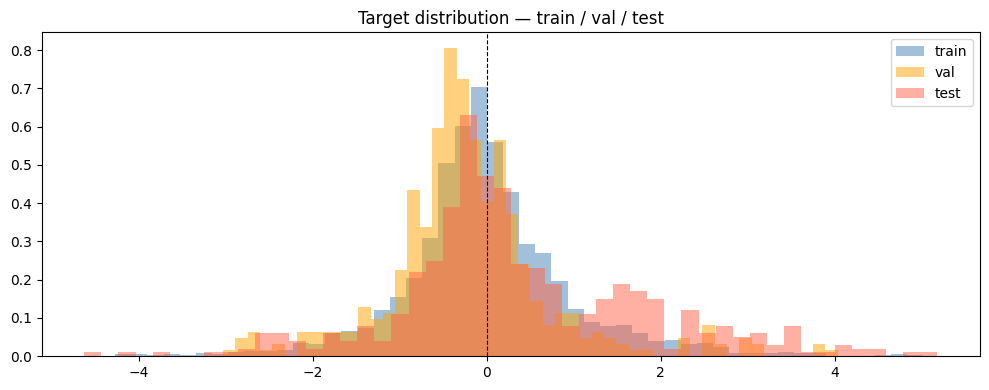


── Scorecard ───────────────────────────────────────────────────────────
  ✓  |y_train_tensor.mean()| ∈ [0, 0.05]
  ✓  y_train_tensor.std() ∈ [0.95, 1.05]
  ✓  |y_val_tensor.mean()| ∈ [0, 0.50]
  ✓  y_val_tensor.std() ∈ [0.80, 1.20]
  ✓  |y_test_tensor.mean()| ∈ [0, 0.50]
  ✓  y_test_tensor.std() ∈ [0.80, 1.50]

  Passed : 6/6  (100%)  ✓ EXCELLENT

  => Proceed to cell 3


In [251]:
print_header("DATA EVALUATOR — Cell 2: Target Distribution")
passed_checks = {}

# ── 2a. StandardScaler sanity ─────────────────────────────────────────────────
print_section("Train target  (StandardScaler sanity)")

passed_checks["|y_train_tensor.mean()| ∈ [0, 0.05]"] = check_metric(
    "|y_train_tensor.mean()|",
    abs(y_train_tensor.mean()),
    lo=0.00,
    hi=0.05,
    fail_lo=0.00,
    fail_hi=0.10,
    meaning="Mean should be ~0 after scaling",
)

passed_checks["y_train_tensor.std() ∈ [0.95, 1.05]"] = check_metric(
    "y_train_tensor.std()",
    y_train_tensor.std(),
    lo=0.95,
    hi=1.05,
    fail_lo=0.90,
    fail_hi=1.10,
    meaning="StandardScaler fit correctly",
)

# ── 2b. Val distribution ──────────────────────────────────────────────────────
print_section("Val target  (regime shift check)")

passed_checks["|y_val_tensor.mean()| ∈ [0, 0.50]"] = check_metric(
    "|y_val_tensor.mean()|",
    abs(y_val_tensor.mean()),
    lo=0.00,
    hi=0.50,
    fail_lo=0.00,
    fail_hi=1.00,
    meaning="Val period not too far from train mean",
)

passed_checks["y_val_tensor.std() ∈ [0.80, 1.20]"] = check_metric(
    "y_val_tensor.std()",
    y_val_tensor.std(),
    lo=0.80,
    hi=1.20,
    fail_lo=0.60,
    fail_hi=1.50,
    meaning="Val volatility similar to train",
)

# ── 2c. Test distribution ─────────────────────────────────────────────────────
print_section("Test target  (regime shift check)")

passed_checks["|y_test_tensor.mean()| ∈ [0, 0.50]"] = check_metric(
    "|y_test_tensor.mean()|",
    abs(y_test_tensor.mean()),
    lo=0.00,
    hi=0.50,
    fail_lo=0.00,
    fail_hi=1.00,
    meaning="Test period regime shift from train",
)

passed_checks["y_test_tensor.std() ∈ [0.80, 1.50]"] = check_metric(
    "y_test_tensor.std()",
    y_test_tensor.std(),
    lo=0.80,
    hi=1.50,
    fail_lo=0.00,
    fail_hi=2.00,
    meaning="Test volatility vs train volatility",
)

# ── 2d. Raw stats ─────────────────────────────────────────────────────────────
print_section("Raw stats")

for name, arr in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    print(
        f"  {name:<10} mean={arr.mean():+.4f}  std={arr.std():.4f}  "
        f"min={arr.min():+.4f}  max={arr.max():+.4f}  n={len(arr)}"
    )

# ── 2e. Distribution plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for arr, label, color in [
    (y_train_tensor, "train", "steelblue"),
    (y_val_tensor, "val", "orange"),
    (y_test_tensor, "test", "tomato"),
]:
    ax.hist(arr, bins=50, alpha=0.5, density=True, label=label, color=color)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Target distribution — train / val / test")
ax.legend()
plt.tight_layout()
plt.show()

passed, total = print_scorecard(passed_checks)
print()
print(
    f"  {'=> Proceed to cell 3' if passed >= 5 else '=> investigate distribution shift before modelling'}"
)

In [252]:
print_header("DATA EVALUATOR — Cell 3: Alignment & Integrity")
passed_checks = {}

# ── 3a. Shape sanity ──────────────────────────────────────────────────────────
print_section("Array shapes")

for name, X, y, d in [
    ("train", X_train_tensor, y_train_tensor, dates_train),
    ("val", X_val_tensor, y_val_tensor, dates_val),
    ("test", X_test_tensor, y_test_tensor, dates_test),
]:
    shape_ok = X.shape[0] == y.shape[0] == d.shape[0]
    dims_ok = X.ndim == 3 and X.shape[1] == LOOKBACK_WINDOW
    ok = shape_ok and dims_ok
    passed_checks[f"{name} X/y/dates aligned"] = ok
    print(
        f"  {'✓' if ok else '✗'}  {name:<6}  X={X.shape}  y={y.shape}  "
        f"dates={d.shape}  "
        f"{'✓ aligned' if shape_ok else '✗ LENGTH MISMATCH'}  "
        f"{'✓ lookback ok' if dims_ok else f'✗ expected lookback={LOOKBACK_WINDOW}'}"
    )

# ── 3b. NaN / Inf checks ──────────────────────────────────────────────────────
print_section("NaN / Inf in arrays")

for name, arr in [
    ("X_train_tensor", X_train_tensor),
    ("X_val_tensor", X_val_tensor),
    ("X_test_tensor", X_test_tensor),
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    ok = n_nan == 0 and n_inf == 0
    passed_checks[f"{name} no NaN/Inf"] = ok
    print(
        f"  {'✓ PASS' if ok else '✗ FAIL'}  {name:<10}  "
        f"NaN={n_nan}  Inf={n_inf}  "
        f"{'clean' if ok else '← FIX BEFORE TRAINING'}"
    )

# ── 3c. Feature count ─────────────────────────────────────────────────────────
print_section("Feature count & sample/feature ratio")

n_features = X_train_tensor.shape[2]
print(f"  [INFO]  Features in X : {n_features}")

for name, X, y in [
    ("train", X_train_tensor, y_train_tensor),
    ("val", X_val_tensor, y_val_tensor),
    ("test", X_test_tensor, y_test_tensor),
]:
    ratio = len(y) / n_features
    ok = ratio >= 20
    passed_checks[f"{name} sample/feature ratio ≥ 20×"] = ok
    check_metric(
        f"{name} samples/features",
        ratio,
        lo=20,
        hi=9999,
        fail_lo=10,
        fail_hi=9999,
        meaning=f"{len(y)} samples / {n_features} features",
    )

# ── 3d. make_windows index alignment ─────────────────────────────────────────
print_section("make_windows index alignment  (gap must equal FORECAST_HORIZON)")

window_ok = True
for i in range(5):
    today_idx = i + LOOKBACK_WINDOW - 1
    future_idx = i + LOOKBACK_WINDOW + FORECAST_HORIZON - 1
    gap = future_idx - today_idx
    ok = gap == FORECAST_HORIZON
    if not ok:
        window_ok = False
    print(
        f"  {'✓' if ok else '✗'}  window {i}: "
        f"today_idx={today_idx}  future_idx={future_idx}  "
        f"gap={gap}  (expected {FORECAST_HORIZON})"
    )

passed_checks[f"make_windows gap == FORECAST_HORIZON ({FORECAST_HORIZON})"] = window_ok

# ── 3e. Date continuity ───────────────────────────────────────────────────────
print_section("Date continuity  (max gap between consecutive dates)")

for name, dates in [
    ("train", dates_train),
    ("val", dates_val),
    ("test", dates_test),
]:
    dts = pd.to_datetime(dates)
    gaps = (dts[1:] - dts[:-1]).days
    max_gap = int(gaps.max())
    n_large = int((gaps > 5).sum())
    ok = max_gap <= 10
    passed_checks[f"{name} date max gap ≤ 10 days"] = ok
    print(
        f"  {'✓ PASS' if ok else '✗ FAIL'}  {name:<6}  "
        f"max_gap={max_gap} days  gaps>5days={n_large}  "
        f"{'✓ ok' if ok else '← possible missing data'}"
    )

# ── 3f. Dataset size ──────────────────────────────────────────────────────────
print_section("Dataset sizes")

for name, y in [
    ("train", y_train_tensor),
    ("val", y_val_tensor),
    ("test", y_test_tensor),
]:
    ok = len(y) >= 200
    passed_checks[f"{name} n_samples ≥ 200"] = ok
    print(
        f"  {'✓ PASS' if ok else '⚠ WARN'}  {name:<6}  n={len(y):5d}  "
        f"{'✓ sufficient' if len(y) >= 400 else '⚠ small' if len(y) >= 200 else '✗ too small'}"
    )

passed, total = print_scorecard(passed_checks)
print()
print(
    f"  {'=> Proceed to cell 4 (ACF check)' if passed >= total - 1 else '=> fix alignment or NaN issues before continuing'}"
)


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 3: Alignment & Integrity
══════════════════════════════════════════════════════════════════════════════

── Array shapes ────────────────────────────────────────────────────────
  ✓  train   X=(3459, 50, 70)  y=(3459,)  dates=(3459,)  ✓ aligned  ✓ lookback ok
  ✓  val     X=(439, 50, 70)  y=(439,)  dates=(439,)  ✓ aligned  ✓ lookback ok
  ✓  test    X=(510, 50, 70)  y=(510,)  dates=(510,)  ✓ aligned  ✓ lookback ok

── NaN / Inf in arrays ─────────────────────────────────────────────────
  ✓ PASS  X_train_tensor  NaN=0  Inf=0  clean
  ✓ PASS  X_val_tensor  NaN=0  Inf=0  clean
  ✓ PASS  X_test_tensor  NaN=0  Inf=0  clean
  ✓ PASS  y_train_tensor  NaN=0  Inf=0  clean
  ✓ PASS  y_val_tensor  NaN=0  Inf=0  clean
  ✓ PASS  y_test_tensor  NaN=0  Inf=0  clean

── Feature count & sample/feature ratio ────────────────────────────────
  [INFO]  Features in X : 70
  ✓ PASS   train samples/featur


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 4: Target ACF & Overlap Check
══════════════════════════════════════════════════════════════════════════════

── Overlapping ACF vs theoretical formula  (5-k)/5 ─────────────────────
  Lag      Theoretical      Train        Val       Test  Match?
  --------------------------------------------------------------
  L1             0.800     +0.844     +0.841     +0.865  ✓ overlap
  L2             0.600     +0.655     +0.644     +0.661  ✓ overlap
  L3             0.400     +0.462     +0.463     +0.437  ✓ overlap
  L4             0.200     +0.278     +0.273     +0.223  ✓ overlap
  L5             0.000     +0.099     +0.109     +0.050  ✓ overlap
  L6             0.000     +0.071     +0.092     +0.022  ✓ overlap
  L7             0.000     +0.064     +0.076     +0.040  ✓ overlap
  L8             0.000     +0.060     +0.062     +0.073  ✓ overlap
  L9             0.000     +0.048     +0.018    

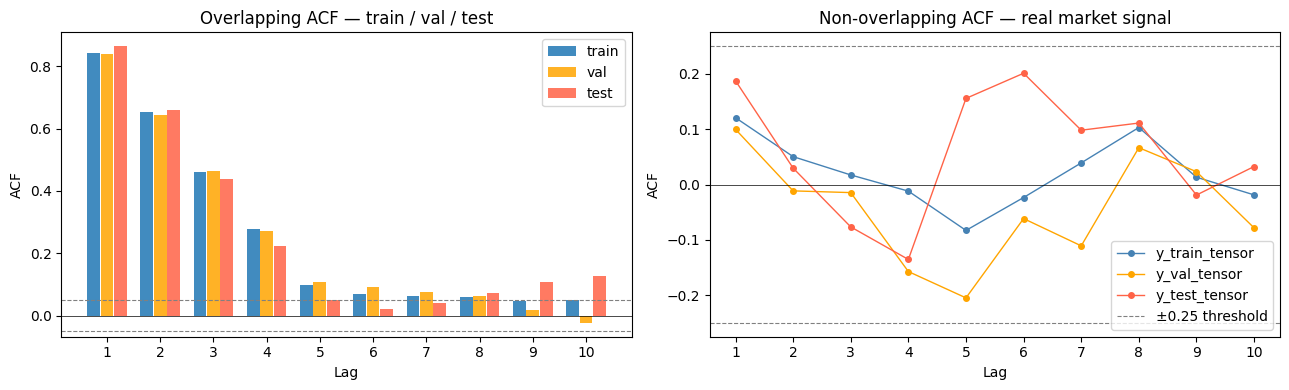


── Case verdict ────────────────────────────────────────────────────────
  ✓ PASS   Max |ACF| train                     val=0.8439   expected=[0.5, 1.0]   should be high if overlap present
  ✓ PASS   Max |ACF| test                      val=0.8651   expected=[0.5, 1.0]   should be high if overlap present

  => CASE C: Overlap present in both. Fix: stride=FORECAST_HORIZON.

── Scorecard ───────────────────────────────────────────────────────────
  ✓  ≥ 4/5 lags match overlap formula
  ✓  y_train_tensor non-overlap ACF L1 < 0.25
  ✓  y_val_tensor non-overlap ACF L1 < 0.25
  ✓  y_test_tensor non-overlap ACF L1 < 0.25
  ✓  Max |ACF| train > 0.5 (overlap present)
  ✓  Max |ACF| test  > 0.5 (overlap present)

  Passed : 6/6  (100%)  ✓ EXCELLENT

  => Proceed to cell 5 (overlap proof)


In [253]:
print_header("DATA EVALUATOR — Cell 4: Target ACF & Overlap Check")
passed_checks = {}

# ── 4a. Overlapping ACF vs theoretical formula ────────────────────────────────
print_section("Overlapping ACF vs theoretical formula  (5-k)/5")

print(
    f"  {'Lag':<6} {'Theoretical':>13} {'Train':>10} {'Val':>10} "
    f"{'Test':>10}  Match?"
)
print(f"  {'-'*62}")

acf_results = {}
for split, y_true in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    acf_results[split] = [pearsonr(y_true[:-k], y_true[k:])[0] for k in range(1, 11)]

overlap_matches = []
for k in range(1, 11):
    theoretical = max(0.0, (FORECAST_HORIZON - k) / FORECAST_HORIZON)
    actual_train = acf_results["y_train_tensor"][k - 1]
    actual_test = acf_results["y_test_tensor"][k - 1]
    diff = abs(actual_train - theoretical)
    match = diff < 0.15
    overlap_matches.append(match)
    print(
        f"  L{k:<5} {theoretical:>13.3f} {actual_train:>+10.3f} "
        f"{acf_results['y_val_tensor'][k-1]:>+10.3f} {actual_test:>+10.3f}  "
        f"{'✓ overlap' if match else '? other'}"
    )

n_matching = sum(overlap_matches[:5])
passed_checks["≥ 4/5 lags match overlap formula"] = n_matching >= 4
print(
    f"\n  Lags 1–5 matching formula : {n_matching}/5  "
    f"{'✓ overlap confirmed' if n_matching >= 4 else '⚠ partial match'}"
)

# ── 4b. Non-overlapping ACF ───────────────────────────────────────────────────
print_section("Non-overlapping ACF  (stride=FORECAST_HORIZON, real signal only)")

print(f"  {'Split':<12} {'L1':>8} {'L2':>8} {'L3':>8} {'L4':>8} " f"{'L5':>8}  Clean?")
print(f"  {'-'*60}")

acf_nol_l1_train = None
for split, y_true in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    y_nl = y_true[::FORECAST_HORIZON]
    acf_nl = [
        pearsonr(y_nl[:-k], y_nl[k:])[0] if len(y_nl) > k else 0 for k in range(1, 6)
    ]
    clean = all(abs(v) < 0.25 for v in acf_nl)
    passed_checks[f"{split} non-overlap ACF L1 < 0.25"] = abs(acf_nl[0]) < 0.25
    vals = "  ".join(f"{v:>+8.3f}" for v in acf_nl)
    print(f"  {split:<12} {vals}  {'✓ clean' if clean else '⚠ check'}")

    if split == "y_train_tensor":
        acf_nol_l1_train = abs(acf_nl[0])
        acf_ol_l1_train = acf_results["y_train_tensor"][0]

    check_metric(
        f"{split} non-overlap ACF L1",
        abs(acf_nl[0]),
        lo=0.00,
        hi=0.25,
        fail_lo=0.00,
        fail_hi=0.35,
        meaning="< 0.25 = real signal only after stride fix",
    )

# ── 4c. ACF drop magnitude ────────────────────────────────────────────────────
print_section("ACF drop: overlapping => non-overlapping")

for split, y_true in [
    ("y_train_tensor", y_train_tensor),
    ("y_val_tensor", y_val_tensor),
    ("y_test_tensor", y_test_tensor),
]:
    acf_ol = acf_results[split][0]
    y_nl = y_true[::FORECAST_HORIZON]
    acf_nol = pearsonr(y_nl[:-1], y_nl[1:])[0]
    drop = acf_ol - acf_nol
    art_pct = drop / acf_ol * 100 if acf_ol != 0 else 0
    print(
        f"  {split:<10}  overlapping L1={acf_ol:+.3f}  "
        f"non-overlapping L1={acf_nol:+.3f}  "
        f"drop={drop:+.3f}  ({art_pct:.0f}% was artificial)"
    )

# ── 4d. ACF bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(1, 11)
axes[0].bar(
    x - 0.25, acf_results["y_train_tensor"], width=0.24, label="train", alpha=0.85
)
axes[0].bar(
    x, acf_results["y_val_tensor"], width=0.24, label="val", alpha=0.85, color="orange"
)
axes[0].bar(
    x + 0.25,
    acf_results["y_test_tensor"],
    width=0.24,
    label="test",
    alpha=0.85,
    color="tomato",
)
axes[0].axhline(0.05, color="gray", linewidth=0.8, linestyle="--")
axes[0].axhline(-0.05, color="gray", linewidth=0.8, linestyle="--")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("ACF")
axes[0].legend()
axes[0].set_title("Overlapping ACF — train / val / test")

for split, y_true, color in [
    ("y_train_tensor", y_train_tensor, "steelblue"),
    ("y_val_tensor", y_val_tensor, "orange"),
    ("y_test_tensor", y_test_tensor, "tomato"),
]:
    y_nl = y_true[::FORECAST_HORIZON]
    acf_nl = [
        pearsonr(y_nl[:-k], y_nl[k:])[0] if len(y_nl) > k else 0 for k in range(1, 11)
    ]
    axes[1].plot(
        range(1, 11),
        acf_nl,
        marker="o",
        label=split,
        color=color,
        linewidth=1,
        markersize=4,
    )

axes[1].axhline(
    0.25, color="gray", linewidth=0.8, linestyle="--", label="±0.25 threshold"
)
axes[1].axhline(-0.25, color="gray", linewidth=0.8, linestyle="--")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xticks(range(1, 11))
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("ACF")
axes[1].legend()
axes[1].set_title("Non-overlapping ACF — real market signal")

plt.tight_layout()
plt.show()

# ── 4e. Case verdict ─────────────────────────────────────────────────────────
train_acf_max = max(abs(v) for v in acf_results["y_train_tensor"])
test_acf_max = max(abs(v) for v in acf_results["y_test_tensor"])

passed_checks["Max |ACF| train > 0.5 (overlap present)"] = train_acf_max > 0.50
passed_checks["Max |ACF| test  > 0.5 (overlap present)"] = test_acf_max > 0.50

print_section("Case verdict")
check_metric(
    "Max |ACF| train",
    train_acf_max,
    lo=0.50,
    hi=1.00,
    fail_lo=0.00,
    fail_hi=1.00,
    meaning="should be high if overlap present",
)
check_metric(
    "Max |ACF| test",
    test_acf_max,
    lo=0.50,
    hi=1.00,
    fail_lo=0.00,
    fail_hi=1.00,
    meaning="should be high if overlap present",
)
print()

if train_acf_max < 0.08 and test_acf_max < 0.08:
    print("  => CASE A: Near-random walk. Fix: 1-day return or macro features.")
elif train_acf_max >= 0.08 and test_acf_max < 0.08:
    print("  => CASE B: Regime change. Fix: walk-forward retraining.")
else:
    print("  => CASE C: Overlap present in both. Fix: stride=FORECAST_HORIZON.")

passed, total = print_scorecard(passed_checks)
print()
print(
    f"  {'=> Proceed to cell 5 (overlap proof)' if passed >= total - 1 else '=> review ACF results before continuing'}"
)


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 5: Overlap Proof & Dataset Size
══════════════════════════════════════════════════════════════════════════════

── Theoretical vs actual ACF  (5-k)/5 formula ──────────────────────────
  Lag      Theoretical      Train       Test    |diff|  Match?
  ----------------------------------------------------------
  L1             0.800     +0.844     +0.865     0.044  ✓ overlap
  L2             0.600     +0.655     +0.661     0.055  ✓ overlap
  L3             0.400     +0.462     +0.437     0.062  ✓ overlap
  L4             0.200     +0.278     +0.223     0.078  ✓ overlap
  L5             0.000     +0.099     +0.050     0.099  ✓ overlap
  L6             0.000     +0.071     +0.022     0.071  ✓ overlap
  L7             0.000     +0.064     +0.040     0.064  ✓ overlap
  L8             0.000     +0.060     +0.073     0.060  ✓ overlap
  L9             0.000     +0.048     +0.109     0.048  ✓ o

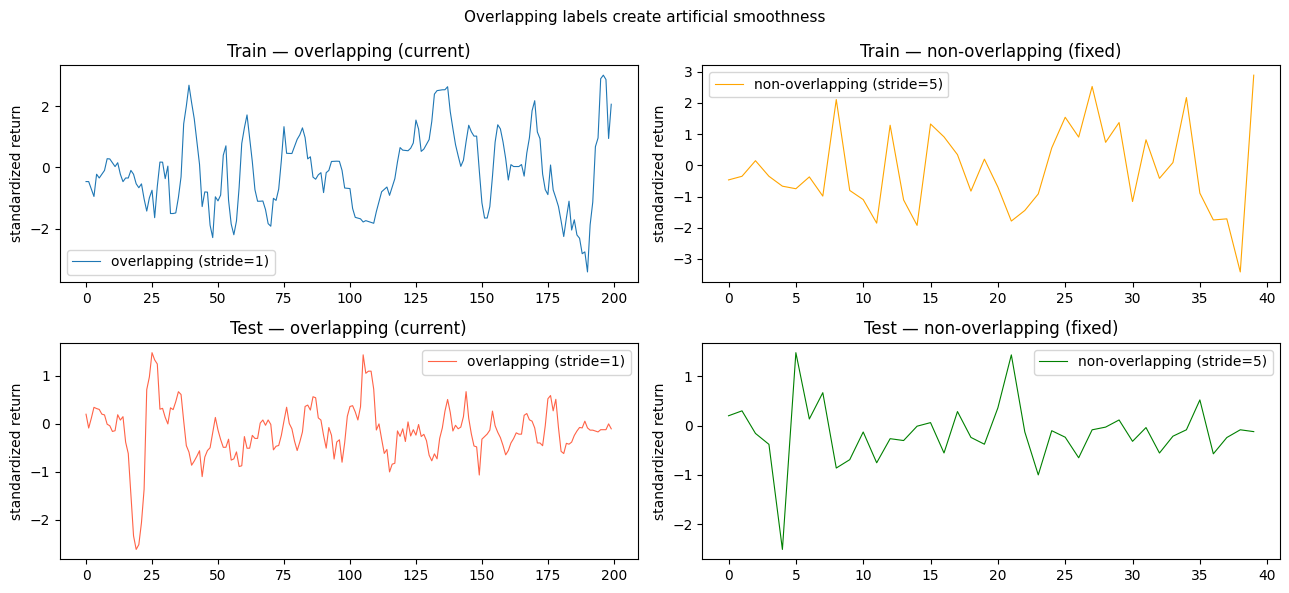


── Dataset size: current vs stride-fixed ───────────────────────────────
  Split       Current    Strided    Ratio current    Ratio fixed
  --------------------------------------------------------------
  train          3459        692             49.4×            9.9×  ✓
  val             439         88              6.3×            1.3×  ⚠ small
  test            510        102              7.3×            1.5×  ⚠ small
  ✓ PASS   train strided samples               val=692   expected=[200, 99999]   < 200 = walk-forward CV will be noisy

── Root cause verdict ──────────────────────────────────────────────────
  ✓ ROOT CAUSE CONFIRMED: overlapping labels

  stride=1 + horizon=5 => y[t] and y[t+1] share 4/5 price days
  => artificial ACF inflated => model learned smoothing, not prediction

  FIX A (recommended): stride=FORECAST_HORIZON in make_windows
  FIX B: change target to 1-day return (horizon=1)

── Scorecard ───────────────────────────────────────────────────────────
  ✓  ≥ 4/5 

In [254]:
N_FEATURES = X_train_tensor.shape[2]  # original feature count before selection

print_header("DATA EVALUATOR — Cell 5: Overlap Proof & Dataset Size")
passed_checks = {}

# ── 5a. Theoretical vs actual ACF ────────────────────────────────────────────
print_section("Theoretical vs actual ACF  (5-k)/5 formula")

print(
    f"  {'Lag':<6} {'Theoretical':>13} {'Train':>10} {'Test':>10}  "
    f"{'|diff|':>8}  Match?"
)
print(f"  {'-'*58}")

overlap_matches = []
for k in range(1, 11):
    theoretical = max(0.0, (FORECAST_HORIZON - k) / FORECAST_HORIZON)
    actual_train = acf_results["y_train_tensor"][k - 1]
    actual_test = acf_results["y_test_tensor"][k - 1]
    diff = abs(actual_train - theoretical)
    match = diff < 0.15
    overlap_matches.append(match)
    print(
        f"  L{k:<5} {theoretical:>13.3f} {actual_train:>+10.3f} "
        f"{actual_test:>+10.3f}  {diff:>8.3f}  "
        f"{'✓ overlap' if match else '? other'}"
    )

n_match = sum(overlap_matches[:5])
passed_checks["≥ 4/5 lags match overlap formula"] = n_match >= 4
print(
    f"\n  Lags 1–5 matching : {n_match}/5  "
    f"{'✓ overlap confirmed' if n_match >= 4 else '⚠ partial'}"
)

# ── 5b. Non-overlapping ACF comparison ───────────────────────────────────────
print_section("ACF: overlapping vs non-overlapping  (stride=FORECAST_HORIZON)")

for label, y_ol in [("train", y_train_tensor), ("test", y_test_tensor)]:
    y_nol = y_ol[::FORECAST_HORIZON]
    acf_ol = [pearsonr(y_ol[:-k], y_ol[k:])[0] for k in range(1, 6)]
    acf_nol = [
        pearsonr(y_nol[:-k], y_nol[k:])[0] if len(y_nol) > k else 0 for k in range(1, 6)
    ]
    drop_L1 = acf_ol[0] - acf_nol[0]
    art_pct = drop_L1 / acf_ol[0] * 100 if acf_ol[0] != 0 else 0

    print(
        f"  [{label}] overlapping   "
        + "  ".join(f"L{k}={v:+.3f}" for k, v in enumerate(acf_ol, 1))
    )
    print(
        f"  [{label}] non-overlap   "
        + "  ".join(f"L{k}={v:+.3f}" for k, v in enumerate(acf_nol, 1))
    )
    print(
        f"  [{label}] ACF L1 drop   "
        f"{acf_ol[0]:+.3f} => {acf_nol[0]:+.3f}  "
        f"({art_pct:.0f}% was artificial)"
    )
    print()

    passed_checks[f"{label} non-overlap L1 < 0.25"] = abs(acf_nol[0]) < 0.25
    check_metric(
        f"{label} non-overlap ACF L1",
        abs(acf_nol[0]),
        lo=0.00,
        hi=0.25,
        fail_lo=0.00,
        fail_hi=0.35,
        meaning="< 0.25 = overlap was the cause, not real market signal",
    )

# ── 5c. Visual ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

axes[0, 0].plot(y_train_tensor[:200], linewidth=0.8, label="overlapping (stride=1)")
axes[0, 0].set_title("Train — overlapping (current)")
axes[0, 0].set_ylabel("standardized return")
axes[0, 0].legend()

axes[0, 1].plot(
    y_train_tensor[::FORECAST_HORIZON][:40],
    linewidth=0.8,
    color="orange",
    label="non-overlapping (stride=5)",
)
axes[0, 1].set_title("Train — non-overlapping (fixed)")
axes[0, 1].set_ylabel("standardized return")
axes[0, 1].legend()

axes[1, 0].plot(
    y_test_tensor[:200], linewidth=0.8, color="tomato", label="overlapping (stride=1)"
)
axes[1, 0].set_title("Test — overlapping (current)")
axes[1, 0].set_ylabel("standardized return")
axes[1, 0].legend()

axes[1, 1].plot(
    y_test_tensor[::FORECAST_HORIZON][:40],
    linewidth=0.8,
    color="green",
    label="non-overlapping (stride=5)",
)
axes[1, 1].set_title("Test — non-overlapping (fixed)")
axes[1, 1].set_ylabel("standardized return")
axes[1, 1].legend()

plt.suptitle("Overlapping labels create artificial smoothness", fontsize=11)
plt.tight_layout()
plt.show()

# ── 5d. Dataset size ──────────────────────────────────────────────────────────
print_section("Dataset size: current vs stride-fixed")

print(
    f"  {'Split':<8} {'Current':>10} {'Strided':>10}  "
    f"{'Ratio current':>15}  {'Ratio fixed':>13}"
)
print(f"  {'-'*62}")

for split, y_arr in [
    ("train", y_train_tensor),
    ("val", y_val_tensor),
    ("test", y_test_tensor),
]:
    n_cur = len(y_arr)
    n_stride = len(y_arr[::FORECAST_HORIZON])
    passed_checks[f"{split} strided n ≥ 200"] = n_stride >= 200
    print(
        f"  {split:<8} {n_cur:>10d} {n_stride:>10d}  "
        f"{n_cur/N_FEATURES:>15.1f}×  {n_stride/N_FEATURES:>13.1f}×  "
        f"{'✓' if n_stride >= 200 else '⚠ small'}"
    )

n_original_train = len(y_train_tensor)
n_strided_train = len(y_train_tensor[::FORECAST_HORIZON])
n_original_features = N_FEATURES

check_metric(
    "train strided samples",
    n_strided_train,
    lo=200,
    hi=99999,
    fail_lo=100,
    fail_hi=99999,
    meaning="< 200 = walk-forward CV will be noisy",
    fmt=".0f",
)

# ── 5e. Root cause verdict ────────────────────────────────────────────────────
print_section("Root cause verdict")

overlap_confirmed = passed_checks.get("≥ 4/5 lags match overlap formula", False)
acf_drop_confirmed = passed_checks.get("train non-overlap L1 < 0.25", False)

if overlap_confirmed and acf_drop_confirmed:
    print("  ✓ ROOT CAUSE CONFIRMED: overlapping labels")
    print()
    print(
        f"  stride=1 + horizon={FORECAST_HORIZON} => y[t] and y[t+1] share "
        f"{FORECAST_HORIZON-1}/{FORECAST_HORIZON} price days"
    )
    print("  => artificial ACF inflated => model learned smoothing, not prediction")
    print()
    print("  FIX A (recommended): stride=FORECAST_HORIZON in make_windows")
    print("  FIX B: change target to 1-day return (horizon=1)")
elif overlap_confirmed:
    print("  ⚠ Overlap present but ACF did not drop — real ACF also present.")
    print("  Apply stride fix AND investigate feature signal separately.")
else:
    print("  ⚠ Overlap not confirmed. Investigate raw price data quality.")

passed, total = print_scorecard(passed_checks)
print()
print(
    f"  {'=> proceed to cell 6 (feature selection + rebuild)' if passed >= total - 1 else '=> review overlap results before rebuilding'}"
)

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
TARGET_COLUMN = "adjust"
LOOKBACK_WINDOW_NEW = 20
FORECAST_HORIZON_NEW = 5
STRIDE_NEW = 5
N_FEATURES = 20

# train_featured_stock_df, val_featured_stock_df, test_featured_stock_df
# must be in memory (loaded from database or parquet)
# X_train_tensor (windowed, shape N×50×70) must be in memory from cell 3

print_header("DATA EVALUATOR — Cell 6: Feature Selection & Stride-Fixed Dataset")
passed_checks = {}

# ── 6a. Load pre-windowed scaled arrays ──────────────────────────────────────
print_section("Load pre-windowed scaled arrays")

required = [
    "train_featured_scaled_stock_tensor.npy",
    "val_featured_scaled_stock_tensor.npy",
    "test_featured_scaled_stock_tensor.npy",
]
missing = [
    f for f in required if not os.path.exists(f"{STOCK_CODE_INPUT_FOLDER_PATH}/{f}")
]

if missing:
    for f in missing:
        print(f"  ✗ MISSING  {STOCK_CODE_INPUT_FOLDER_PATH}/{f}")
    print()
    print("  => Add to train_test_creator.ipynb cell 7 and re-run:")
    print(
        "    np.save(f'{TRAIN_TEST_SET_STOCK_CODE}/train_featured_scaled_stock_tensor.npy', train_featured_scaled_stock_tensor)"
    )
    print(
        "    np.save(f'{TRAIN_TEST_SET_STOCK_CODE}/val_featured_scaled_stock_tensor.npy',   val_featured_scaled_stock_tensor)"
    )
    print(
        "    np.save(f'{TRAIN_TEST_SET_STOCK_CODE}/test_featured_scaled_stock_tensor.npy',  test_featured_scaled_stock_tensor)"
    )
    raise FileNotFoundError("Pre-windowed scaled arrays missing.")

for name, arr in [
    ("train_featured_scaled_stock_tensor", train_featured_scaled_stock_tensor),
    ("val_featured_scaled_stock_tensor", val_featured_scaled_stock_tensor),
    ("test_featured_scaled_stock_tensor", test_featured_scaled_stock_tensor),
]:
    ok = arr.ndim == 2 and np.isnan(arr).sum() == 0
    passed_checks[f"{name} 2D + no NaN"] = ok
    print(
        f"  {'✓ PASS' if ok else '✗ FAIL'}  {name:<18}  "
        f"shape={arr.shape}  NaN={np.isnan(arr).sum()}"
    )

# ── 6b. Mutual information feature selection ──────────────────────────────────
print_section(
    f"Mutual information — top {N_FEATURES} from "
    f"{train_featured_scaled_stock_tensor.shape[1]} features"
)

X_flat = X_train_tensor[:, -1, :]
y_flat = y_train_tensor
mi_scores = mutual_info_regression(X_flat, y_flat, random_state=42)
mi_df = (
    pd.DataFrame({"feature_idx": np.arange(len(mi_scores)), "mi_score": mi_scores})
    .sort_values("mi_score", ascending=False)
    .reset_index(drop=True)
)

top_features = mi_df["feature_idx"].iloc[:N_FEATURES].values
mi_top_mean = mi_df["mi_score"].iloc[:N_FEATURES].mean()
mi_drop_mean = mi_df["mi_score"].iloc[N_FEATURES:].mean()
mi_gap = mi_top_mean - mi_drop_mean

passed_checks[f"Top {N_FEATURES} MI > dropped MI"] = mi_top_mean > mi_drop_mean
passed_checks["MI gap > 0.001"] = mi_gap > 0.001

print(f"  Top {N_FEATURES} indices : {sorted(top_features.tolist())}")
check_metric(
    "Top-N mean MI",
    mi_top_mean,
    lo=0.005,
    hi=9999,
    fail_lo=0.001,
    fail_hi=9999,
    meaning="MI > 0.005 = features carry real signal",
)
check_metric(
    "Dropped mean MI",
    mi_drop_mean,
    lo=0.000,
    hi=9999,
    fail_lo=0.000,
    fail_hi=9999,
    meaning="should be lower than top-N",
)
check_metric(
    "MI gap",
    mi_gap,
    lo=0.001,
    hi=9999,
    fail_lo=0.000,
    fail_hi=9999,
    meaning="larger = cleaner feature separation",
)

train_featured_scaled_selected_stock_tensor = train_featured_scaled_stock_tensor[
    :, top_features
]
val_featured_scaled_selected_stock_tensor = val_featured_scaled_stock_tensor[:, top_features]
test_featured_scaled_selected_stock_tensor = test_featured_scaled_stock_tensor[:, top_features]
print(
    f"\n  After selection: train={train_featured_scaled_selected_stock_tensor.shape} | "
    f"val={val_featured_scaled_stock_tensor.shape} | test={test_featured_scaled_stock_tensor.shape}"
)

# ── 6c. make_windows_strided ──────────────────────────────────────────────────
print_section(
    f"make_windows_strided  "
    f"(lookback={LOOKBACK_WINDOW_NEW}, horizon={FORECAST_HORIZON_NEW}, stride={STRIDE_NEW})"
)


def make_windows_strided(
    X_scaled, source_df, target_col, lookback, forecast_horizon, stride
):
    assert (
        stride >= forecast_horizon
    ), f"stride={stride} < forecast_horizon={forecast_horizon}: labels will overlap"
    prices = source_df[target_col].values
    dates = source_df["date"].values
    total = lookback + forecast_horizon
    X_list, y_list, d_list = [], [], []
    for i in range(0, len(X_scaled) - total + 1, stride):
        today_idx = i + lookback - 1
        future_idx = i + lookback + forecast_horizon - 1
        X_list.append(X_scaled[i : i + lookback])
        y_list.append(prices[future_idx] / prices[today_idx] - 1)
        d_list.append(dates[today_idx])
    return np.array(X_list), np.array(y_list), np.array(d_list)


X_tr, y_tr, d_tr = make_windows_strided(
    train_featured_scaled_selected_stock_tensor,
    train_featured_stock_df,
    TARGET_COLUMN,
    LOOKBACK_WINDOW_NEW,
    FORECAST_HORIZON_NEW,
    STRIDE_NEW,
)
X_vl, y_vl, d_vl = make_windows_strided(
    val_featured_scaled_stock_tensor,
    val_featured_stock_df,
    TARGET_COLUMN,
    LOOKBACK_WINDOW_NEW,
    FORECAST_HORIZON_NEW,
    STRIDE_NEW,
)
X_te, y_te, d_te = make_windows_strided(
    test_featured_scaled_stock_tensor,
    test_featured_stock_df,
    TARGET_COLUMN,
    LOOKBACK_WINDOW_NEW,
    FORECAST_HORIZON_NEW,
    STRIDE_NEW,
)

print(f"\n  {'Split':<8} {'n_samples':>10} {'shape':>20}  {'sample/feat':>12}  Check")
print(f"  {'-'*60}")
for name, X, y in [("train", X_tr, y_tr), ("val", X_vl, y_vl), ("test", X_te, y_te)]:
    ratio = len(y) / N_FEATURES
    ok = len(y) >= 200
    passed_checks[f"{name} strided n ≥ 200"] = ok
    print(
        f"  {name:<8} {len(y):>10d} {str(X.shape):>20}  "
        f"{ratio:>12.1f}×  {'✓' if ok else '⚠ small'}"
    )
    check_metric(
        f"{name} sample/feature ratio",
        ratio,
        lo=20,
        hi=9999,
        fail_lo=10,
        fail_hi=9999,
        meaning="< 10× = risk of overfit even after stride fix",
    )

# ── 6d. Target re-standardization + ACF verify ────────────────────────────────
print_section("Target re-standardization + ACF verification")

target_scaler_new = StandardScaler()
y_tr = target_scaler_new.fit_transform(y_tr.reshape(-1, 1)).flatten()
y_vl = target_scaler_new.transform(y_vl.reshape(-1, 1)).flatten()
y_te = target_scaler_new.transform(y_te.reshape(-1, 1)).flatten()

print(f"  {'Split':<8} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print(f"  {'-'*44}")
for name, arr in [("train", y_tr), ("val", y_vl), ("test", y_te)]:
    print(
        f"  {name:<8} {arr.mean():>+10.4f} {arr.std():>10.4f} "
        f"{arr.min():>+10.4f} {arr.max():>+10.4f}"
    )

passed_checks["|y_tr mean| ≈ 0"] = abs(y_tr.mean()) < 0.05
passed_checks["y_tr std ≈ 1"] = 0.95 <= y_tr.std() <= 1.05
check_metric(
    "|y_tr mean|",
    abs(y_tr.mean()),
    lo=0.00,
    hi=0.05,
    fail_lo=0.00,
    fail_hi=0.10,
    meaning="StandardScaler fit correctly on new train set",
)
check_metric(
    "y_tr std",
    y_tr.std(),
    lo=0.95,
    hi=1.05,
    fail_lo=0.90,
    fail_hi=1.10,
    meaning="StandardScaler fit correctly on new train set",
)

print()
print(f"  {'Split':<8}  ACF L1–L5  (should all be < 0.25)")
print(f"  {'-'*58}")
for name, arr in [("train", y_tr), ("val", y_vl), ("test", y_te)]:
    acf = [pearsonr(arr[:-k], arr[k:])[0] if len(arr) > k else 0 for k in range(1, 6)]
    clean = all(abs(v) < 0.25 for v in acf)
    passed_checks[f"{name} new ACF L1 < 0.25"] = abs(acf[0]) < 0.25
    vals = "  ".join(f"L{k}={v:+.3f}" for k, v in enumerate(acf, 1))
    print(f"  {name:<8}  {vals}  {'✓ clean' if clean else '⚠ check'}")
    check_metric(
        f"{name} new ACF L1",
        abs(acf[0]),
        lo=0.00,
        hi=0.25,
        fail_lo=0.00,
        fail_hi=0.35,
        meaning="< 0.25 = stride fix confirmed working",
    )

passed, total = print_scorecard(passed_checks)
print()
print(
    f"  {'=> data ready — proceed to model_evaluator' if passed >= total - 1 else '=> fix data issues before training'}"
)
print()
print("  Variables exported to model_evaluator:")
print("    X_tr, X_vl, X_te        — feature windows (stride-fixed)")
print("    y_tr, y_vl, y_te        — standardized returns (non-overlapping)")
print("    d_tr, d_vl, d_te        — dates")
print("    top_features            — selected feature indices")
print("    target_scaler_new       — fitted scaler for inference")
print("    mi_df                   — MI scores for all features")
print("    N_FEATURES              — model input size")
print("    n_original_train        — dataset size before stride fix")
print("    n_strided_train         — dataset size after stride fix")
print("    n_original_features     — feature count before selection")
print("    acf_ol_l1_train         — overlapping ACF L1 (for cell 12)")
print("    acf_nol_l1_train        — non-overlapping ACF L1 (for cell 12)")


══════════════════════════════════════════════════════════════════════════════
  DATA EVALUATOR — Cell 6: Feature Selection & Stride-Fixed Dataset
══════════════════════════════════════════════════════════════════════════════

── Load pre-windowed scaled arrays ─────────────────────────────────────
  ✓ PASS  train_featured_scaled_stock_tensor  shape=(3513, 70)  NaN=0
  ✓ PASS  val_featured_scaled_stock_tensor  shape=(493, 70)  NaN=0
  ✓ PASS  test_featured_scaled_stock_tensor  shape=(564, 70)  NaN=0

── Mutual information — top 20 from 70 features ────────────────────────
  Top 20 indices : [0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 15, 16, 18, 20, 29, 30, 38, 45, 46, 52]
  ✓ PASS   Top-N mean MI                       val=0.1844   expected=[0.005, 9999]   MI > 0.005 = features carry real signal
  ✓ PASS   Dropped mean MI                     val=0.0224   expected=[0.0, 9999]   should be lower than top-N
  ✓ PASS   MI gap                              val=0.1620   expected=[0.001, 9999]   larger =